# Case Studies in HPC Homework 2 - GMRES Method
## Notebook for part (1) - Linear Least Squares


In [1]:
#imports

import numpy as np
from numpy import linalg
import matplotlib.pyplot as plt
from scipy.io import mmread

## Function which generates the next column for the H matrix and the next entry for the Krylov basis

In [2]:
def VH_update(H,V,A):

    #generating the diensions of the expanded H matrix
    n,m = H.shape
    Hnew = np.zeros((n+1,m+1))
    Hnew[:n, :m] = H

    #allocating space for a new basis array with one more vector slot
    Vnew = np.zeros((V.shape[0], V.shape[1] + 1))
    Vnew[:, :V.shape[1]] = V

    #array to store the new hvalues to be added to the new matrix
    hstore = np.zeros(n+1)
    hvsum = np.zeros(V.shape[0])

    w = (A @ Vnew[:,m])

    #for loop which creates all but the final value for the new entries in the H matrix using the GMRES alg from Schiltz
    for i in range(n):
        hstore[i] = Vnew[:,i] @ w
        hvsum += hstore[i] * Vnew[:,i]

    #generating the basis vector for the next dimension of the Krylov subspace
    vhat = w - hvsum
    hstore[n] = np.linalg.norm(vhat)

    #Appending the new basis vector
    if hstore[n] > 0:
        Vnew[:,n] = vhat/ hstore[n]
    else:
        print('Orthogonal basis complete') #since the last h being zero would imply that A^n b is inside the previous krylov subspace
        return Hnew, Vnew, 1 #The return of 1 will tell the programme to stop the while loop

    #putting the newly generataed h values into the Hnew matrix
    Hnew[:n+1, m] = hstore

    return Hnew, Vnew, 0

## Function which applies a simple GMRES iteration method


In [3]:
def GMRESsimp(A, b, x0, tol, mx):
    #Creating the first residual from the guess vector
    r0 = A @  x0 - b
    res0 = np.linalg.norm(A @ x0 - b)
    #Checking if the first residual is good enough for the tolerance
    if res0 < tol:
        return x0
    #Creating an array of residuals for plotting later
    residuals = [res0]

    #Defining the array to hold the orthogonal basis of the kryloc subspace
    n = len(b)
    V = np.zeros((n, 2))

    #Appending the first basis vector into the basis
    V[:,0] = r0/res0

    #Here we do the initial Hessenberg construction
    H = np.zeros((2, 1))
    H[0,0] = V[:,0] @ (A @ V[:,0])
    vhat2 = A @ V[:,0] - H[0,0] * V[:,0]
    H[1,0] = np.linalg.norm(vhat2)
    V[:,1]= vhat2/H[1,0]

    #minimising wrt y for the first H matrix
    rhs = np.zeros(H.shape[0])
    rhs[0] = res0
    y, *_ = np.linalg.lstsq(H, rhs, rcond=None)
    res = np.linalg.norm(rhs - H @ y)

    #storing the first new residual
    residuals.append(res)

    #counter to enforce a maximum of iterations on the while loop
    counter = 1

    #while loop which repeats the above process until the tolerance is reached
    while(res >= tol):

        #Generates the new H,V matrices using the Schutz algorithm 
        H, V, check = VH_update(H,V,A)      

        #Minimising with th new H value
        rhs = np.zeros(H.shape[0])
        rhs[0] = res0
        y, *_ = np.linalg.lstsq(H, rhs, rcond=None)
        res = np.linalg.norm(rhs - H @ y)
        residuals.append(res)

        counter +=1

        #break for the hjj = 0 check in the update function
        if check == 1:
            print('Process ended as orthogonal basis complete')
            break

        #break if maximum counter is hit
        if counter == mx:
            print('Process ended as iteration ceiling enforced')
            break    

    if(res <= tol):
        print('Process ended as tolerance reached')


    #recovering x form y
    xfinal = x0 + V[:, :H.shape[1]] @ y
        
    #Returning the final vector and the array of residuals
    return xfinal, residuals 

# Testing the function
## Small Matrix

Opening the matrix file

In [4]:
A = mmread("HW2 Case Studies/cdde6.mtx")

Creating a b vector for the solver

In [43]:
n, m = A.shape
b = np.ones(n)
x0= np.zeros(n)
tol = 0.00000000001
mx = 1000
print(n)

961


Solving the system with our GMRES

In [44]:
xfinals, residuals = GMRESsimp(A,b, x0, tol, mx)

Process ended as tolerance reached


Plotting our result

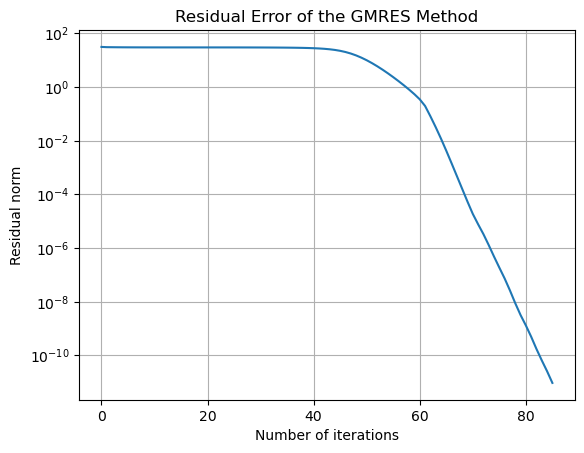

In [45]:
plt.plot(residuals)
plt.grid()
plt.xlabel('Number of iterations')
plt.ylabel('Residual norm')
plt.yscale("log")
plt.title("Residual Error of the GMRES Method")
#plt.savefig("simpGMRESsmalllog.pdf", format = 'pdf')
plt.show()

86

## Large Matrix

In [12]:
B = mmread("HW2 Case Studies/parabolic_fem.mtx")

Setting up the numbers

In [56]:
n, m = B.shape
b = np.ones(n)
x0= np.zeros(n)
tol = 0.001
mx = 800
print(n)
#print(m)

525825


Solving the system with our simple GMRES

In [ ]:
Lxfinals, Lresiduals = GMRESsimp(B,b, x0, tol, mx)
print(Lresiduals[-1])

Plotting the result

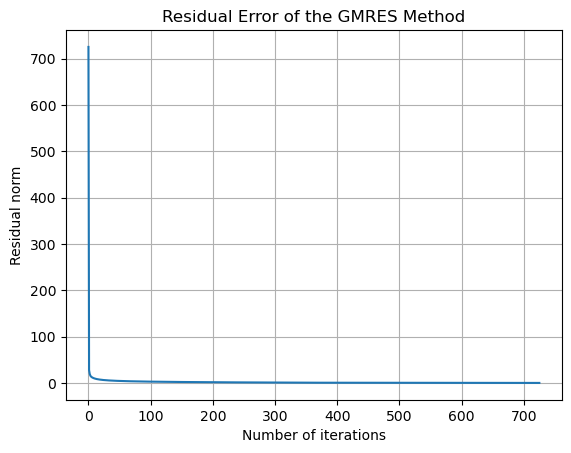

In [53]:
plt.plot(Lresiduals)
plt.grid()
plt.xlabel('Number of iterations')
plt.ylabel('Residual norm')
#plt.yscale("log")
plt.title("Residual Error of the GMRES Method")
#plt.savefig("simpGMRESlarge.pdf", format = 'pdf')
plt.show()